# Scenarios for Hantavirus

After the data analysis performed in Hanta_analysis.ipynb, I use the results to perform uncertainty and sensitivity analysis, construct scenarios of epidemics, and evaluate the efficacy of mitigation measures.

## Imports

In [1]:
# Stats utils
from scipy.stats import iqr
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import nbinom
from scipy.stats import gamma
from scipy.optimize import minimize

# Basci libraries
import pandas as pd
import numpy as np
import datetime
import argparse
import random

# Custom epidemic sims
from src.epidemic_seir_smallworld import run_seir, print_report        # Simulations with constant R0
from src.seir_network_model import run_seir_piecewise, print_summary   # Simulations with piecewise R(t)
from src.seir_incubation_uncertainty import sweep_incubation_range, sample_incubation_gamma_network, seir_delay_gamma_ode_sensitivity, seir_delay_gamma_ode_unc  # For uncertainty analysis and delay SEIR
from src.seir_network_model import run_seir_intervention               # For interventions
from src.seir_ia_quarantine_sweep import sweep_eta_theta, sweep_eta_ts, plot_heatmap_asymptomatic # For asymptomatic cases
from src.seir_superspreading_sweep import sweep_kd, plot_distributions

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

### Defs

In [2]:
# ------ Sampling from distributions
def sample_r0_gaussian(              # Draw ``n`` R0 values from N(mean, std²), clipped to [r0_min, ∞). 
    mean: float,
    std: float,
    n: int,
    r0_min: float = 0.1,
    seed: int = 42,
) -> list[float]:
    rng    = random.Random(seed)
    values = []
    while len(values) < n:
        v = rng.gauss(mean, std)
        if v >= r0_min:              # r0_min is used to avoid meanigless values close or lower than 0, which are instead resampled
            values.append(v)
    return values

def sample_infection_gamma(          # Draw ``n`` R0 values from Gamma(shape, scale), clipped to [alpha_min, ∞).
    a: float,
    scale: float,
    n: int,
    alpha1_min: float = 0.1,
    seed: int = 42,
) -> list[float]:
    rng = np.random.default_rng(seed=42)
    values = []
    while len(values) < n:
        v = rng.gamma(shape = a, scale = scale)
        if v >= alpha1_min:          # alpha_min is used to avoid meanigless values close or lower than 0, which are instead resampled
            values.append(v)
    return values

# ------ Analysis of ensemble trajectories
# Run one ensemble of SEIR simulations (calling the "run_seir" function) for each R0 value, returns a dict of 'R0', 'S', 'E', 'I', 'R'
def run_ensemble(
    r0_values: list[float],
    n_nodes: int,
    incubation_days: float,
    infectious_days: float,
    k: int,
    p_rewire: float,
    base_seed: int,
) -> list[dict]:
    results = []
    for idx, R0 in enumerate(r0_values):
        S, E, I, R, _ = run_seir(
            n_nodes         = n_nodes,
            R0              = R0,
            incubation_days = incubation_days,
            infectious_days = infectious_days,
            k               = k,
            p_rewire        = p_rewire,
            seed            = base_seed + idx,
        )
        results.append({"R0": R0, "S": S, "E": E, "I": I, "R": R})

    # Add best case (R0=0.53) and worst case (R0=5.90) scenarios 
    # (corresponding to min R0 and max R0 ever registered by the fitting analysis and in the literature)
    S, E, I, R, _ = run_seir(
            n_nodes         = n_nodes,
            R0              = 0.53,
            incubation_days = incubation_days,
            infectious_days = infectious_days,
            k               = k,
            p_rewire        = p_rewire,
            seed            = base_seed + 101,
        )
    results.append({"R0": 0.53, "S": S, "E": E, "I": I, "R": R})
    S, E, I, R, _ = run_seir(
            n_nodes         = n_nodes,
            R0              = 5.90,
            incubation_days = incubation_days,
            infectious_days = infectious_days,
            k               = k,
            p_rewire        = p_rewire,
            seed            = base_seed + 102,
        )
    results.append({"R0": 5.90, "S": S, "E": E, "I": I, "R": R})
    return results

# Plotting for uncertainties over R0: separate S, E, I, R into four panels, to have good visibility. Color the trajectories according to the R0 value
def plot_ensemble(
    results:         list[dict],
    r0_mean:         float,
    r0_std:          float,
    n_nodes:         int,
    incubation_days: float,
    infectious_days: float,
    out_path:        str | None = None,
) -> None:
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 8),
                             constrained_layout=True)
 
    compartments = [
        ("S", "Susceptible",  axes[0, 0], "#1565C0"),
        ("E", "Exposed",      axes[0, 1], "#E65100"),
        ("I", "Infectious",   axes[1, 0], "#B71C1C"),
        ("R", "Removed",    axes[1, 1], "#2E7D32"),
    ]
 
    # Colourmap: map each R0 to a colour
    r0_vals = [res["R0"] for res in results]
    r0_vals.remove(0.53)
    r0_vals.remove(5.90)
    r0_min_val, r0_max_val = min(r0_vals), max(r0_vals)
    # Use a diverging map centred on R0_mean
    cmap     = plt.cm.coolwarm
    r0_range = max(r0_max_val - r0_mean, r0_mean - r0_min_val, 1e-6)
    norm     = mcolors.TwoSlopeNorm(
        vmin  = r0_mean - r0_range,
        vcenter = r0_mean,
        vmax  = r0_mean + r0_range,
    )
 
    # Draw trajectories
    for key, label, ax, _ in compartments:
        for res in results:
            series = [v / n_nodes for v in res[key]]   # normalise to [0,1]
            days   = list(range(len(series)))
            color  = cmap(norm(res["R0"]))
            ax.plot(days, series, color=color, alpha=0.55, linewidth=1.2)
 
        # Overlay the trajectory whose R0 is closest to the mean
        closest = min(results, key=lambda r: abs(r["R0"] - r0_mean))
        series  = [v / n_nodes for v in closest[key]]
        ax.plot(range(len(series)), series,
                color="black", linewidth=2.0, linestyle="-",
                label=f"$R_0 \\approx$ {closest['R0']:.2f} (closest to mean)",
                zorder=5)

        # Overlay the trajectory whose R0 is the minimum
        minimum = min(results, key=lambda r: r["R0"])
        series  = [v / n_nodes for v in minimum[key]]
        ax.plot(range(len(series)), series,
                color="black", linewidth=1.0, linestyle=":",
                label=f"$R_0$ = 0.53 (min of CI)",
                zorder=5)

        # Overlay the trajectory whose R0 is the maximum
        maximum = max(results, key=lambda r: r["R0"])
        series  = [v / n_nodes for v in maximum[key]]
        ax.plot(range(len(series)), series,
                color="black", linewidth=1.0, linestyle="--",
                label=f"$R_0$ = 5.90 (max of CI)",
                zorder=5)
 
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Day", fontsize=14)
        ax.set_ylabel("Fraction of population", fontsize=14)
        ax.set_ylim(-0.02, 1.05)
        ax.grid(alpha=0.25, linestyle=":")
        ax.legend(fontsize=8, loc="upper right")
 
    # Shared colourbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(),
                        orientation="vertical", fraction=0.02, pad=0.04)
    cbar.set_label("$R_0$ value", fontsize=11)
 
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"\n  Figure saved to: {out_path}")
 
    plt.show()

# Print a compact table of per-trajectory statistics, for uncertainties over R0.
def print_summary(results: list[dict], n_nodes: int) -> None:
    w = 70
    print(f"\n{'='*w}")
    print(f"  {'R0':>7}  {'Duration':>9}  {'Peak I':>8}  "
          f"{'Day Peak I':>10}  {'Attack %':>9}")
    print(f"  {'-'*7}  {'-'*9}  {'-'*8}  {'-'*10}  {'-'*9}")
    for res in sorted(results, key=lambda r: r["R0"]):
        I = res["I"]
        peak_I   = max(I)
        peak_day = I.index(peak_I)
        total    = n_nodes - res["S"][-1]
        print(f"  {res['R0']:>7.3f}  {len(I)-1:>9}  "
              f"{peak_I:>8}  {peak_day:>10}  "
              f"{total/n_nodes*100:>8.1f}%")
    print(f"{'='*w}\n")

# Plot single median trajectory
def plot_tseries(n_nodes: int,
    R0: float,
    incubation_days: float,
    infectious_days: float,
    superspreading: bool,
    k_disp: float,
    S: list[int],
    E: list[int],
    I: list[int],
    R: list[int],
    ss: list[int]):
    
            days = list(range(len(S)))
            has_ss_events = superspreading and any(ss)

            if has_ss_events:
                fig = plt.figure(figsize=(11, 6))
                gs  = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.4)
                ax1 = fig.add_subplot(gs[0])
                ax2 = fig.add_subplot(gs[1], sharex=ax1)
            else:
                fig, ax1 = plt.subplots(figsize=(10, 5))
                ax2 = None

            ax1.plot(days, S, label="Susceptible (S)", color="#2196F3", linewidth=2)
            ax1.plot(days, E, label="Exposed     (E)", color="#FF9800", linewidth=2, linestyle="--")
            ax1.plot(days, I, label="Infectious  (I)", color="#F44336", linewidth=2)
            ax1.plot(days, R, label="Removed   (R)", color="#4CAF50", linewidth=2)
            ax1.set_ylabel("Count", fontsize=15)
            ss_tag = f", superspreading k={k_disp}" if superspreading else ""
            ax1.legend()
            ax1.grid(alpha=0.3)

            if ax2 is not None:
                ax2.bar(days, ss, color="#9C27B0", alpha=0.75,
                        label="Superspreader events / day")
                ax2.set_xlabel("Day")
                ax2.set_ylabel("Events")
                ax2.legend(fontsize=8)
                ax2.grid(alpha=0.3)
            else:
                ax1.set_xlabel("Day", fontsize=15)

            plt.tight_layout()
            plt.show()


# ------ Analysis of scenarios with parameters sweeps (network and mitigation)

# Plot when varying k
def plot_ensemble_netparam(
    cutoff_time:     int,
    results:         list[dict],
    r0_mean:         float,
    k_mean:          float,
    which_param:     str,
    n_nodes:         int,
    out_path:        str | None = None,
) -> None:
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 8),
                             constrained_layout=True)

    compartments = [
        ("S", "Susceptible",  axes[0, 0], "#1565C0"),
        ("E", "Exposed",      axes[0, 1], "#E65100"),
        ("I", "Infectious",   axes[1, 0], "#B71C1C"),
        ("R", "Removed",    axes[1, 1], "#2E7D32"),
    ]

    cmap = plt.get_cmap("tab10")
 
    # Draw trajectories
    for key, label, ax, _ in compartments:
        for idx, res in enumerate(results):
            series = [v / n_nodes for v in res[key]]   # normalise to [0,1]
            days   = list(range(len(series)))
            color  = cmap(idx)
            ax.plot(days[1:cutoff_time], series[1:cutoff_time], color=color, alpha=0.75, linewidth=1.2, label=f"{which_param} = {res[which_param]:.1f}")
 
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Day", fontsize=14)
        ax.set_ylabel("Fraction of population", fontsize=14)
        ax.grid(alpha=0.25, linestyle=":")
        ax.legend()
 
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"\n  Figure saved to: {out_path}")
 
    plt.show()

# Combined analysis on k and p_rewire
# Get a grid of values for each combination of k (on the rows) and p_rewire (on the columns).
# Use, as order parameter, the cumulative infections up to ``horizon`` days
# Cumulative infections = N − S(min(horizon, T_end)) where T_end is the last simulated day.
def sweep_net_seir(
    k_values:        list[int],
    p_values:        list[float],
    R0:              float,
    n_nodes:         int,
    incubation_days: float,
    infectious_days: float,
    horizon:         int,
    n_replicates:    int,
    base_seed:       int,
) -> np.ndarray:

    nk = len(k_values)
    np_ = len(p_values)
    result = np.zeros((nk, np_), dtype=float)
 
    total = nk * np_
    done  = 0
 
    for i, k in enumerate(k_values):
        for j, p in enumerate(p_values):
            cum_sum = 0.0
            for rep in range(n_replicates):
                seed = base_seed + i * 10_000 + j * 100 + rep
                S, E, I_s, R_s, _ = run_seir(
                    n_nodes         = n_nodes,
                    R0              = R0,
                    incubation_days = incubation_days,
                    infectious_days = infectious_days,
                    k               = k,
                    p_rewire        = p,
                    seed            = seed,
                )
                # Index of the last available day up to the horizon
                t_end   = min(horizon, len(S) - 1)
                cum_inf = n_nodes - S[t_end]
                cum_sum += cum_inf
 
            result[i, j] = cum_sum / n_replicates
            done += 1
            pct  = done / total * 100
 
    #print()
    return result

# Combined analysis on chi and eta (mitigation rates)
# Get a grid of values for each combination of chi (on the rows) and eta (on the columns).
# Use, as order parameter, the cumulative infections up to ``horizon`` days
# Cumulative infections = N − S(min(horizon, T_end)) where T_end is the last simulated day.
def sweep_mitigation_seir(
    k_value:        int,
    p_value:        float,
    R0:              float,
    n_nodes:         int,
    incubation_days: float,
    infectious_days: float,
    horizon:         int,
    n_replicates:    int,
    base_seed:       int,
    chi_values = list[float],
    eta_values = list[float],
    t_intervention = float
) -> np.ndarray:

    nchi = len(chi_values)
    neta = len(eta_values)
    result = np.zeros((nchi, neta), dtype=float)
 
    total = nchi * neta
    done  = 0
 
    for i, chi in enumerate(chi_values):
        for j, eta in enumerate(eta_values):
            cum_sum = 0.0
            for rep in range(n_replicates):
                seed = base_seed + i * 10_000 + j * 100 + rep
                S, E, I, R, IS, Q, ss = run_seir_intervention(      # IS stands for T in the paper (isolated and traced)
                    n_nodes = n_nodes, R0 = R0,
                    incubation_days = incubation_days, infectious_days = infectious_days,
                    t_intervention = t_intervention,  
                    chi = chi,    
                    eta = eta,    
                    k = k_value, p_rewire = p_value, seed = seed,
                )

                # Index of the last available day up to the horizon
                t_end   = min(horizon, len(S) - 1)
                cum_inf = n_nodes - S[t_end]
                cum_sum += cum_inf
 
            result[i, j] = cum_sum / n_replicates
            done += 1
            pct  = done / total * 100
 
    #print()
    return result

# Plot heatmap from the k - p_rewire sweep
# Rows: degree k (y-axis, ascending bottom-to-top). Columns: p_rewire (x-axis, ascending left-to-right). 
# Cell colour: mean cumulative I up to ``horizon`` days
def plot_heatmap(
    data:            np.ndarray,
    k_values:        list[int],
    p_values:        list[float],
    R0:              float,
    n_nodes:         int,
    horizon:         int,
    n_replicates:    int,
    incubation_days: float,
    infectious_days: float,
    out_path:        str | None = None,
) -> None:

    fig, ax = plt.subplots(figsize=(11, 7))
 
    # Flip rows so that k increases upward 
    data_plot    = data[::-1]
    k_labels_rev = k_values[::-1]
 
    # --- Colour map 
    # Sequential map from near-zero (deep purple) to full attack (bright yellow)
    cmap = plt.cm.YlOrRd
    im   = ax.imshow(
        data_plot / n_nodes,      # normalise to attack fraction [0,1]
        cmap   = cmap,
        aspect = "auto",
        vmin   = 0.0,
        vmax   = 1.0,
        origin = "upper",
    )

    ax.set_xticks(range(len(p_values)))
    ax.set_xticklabels([f"{p:.2f}" for p in p_values], fontsize=10)
    ax.set_yticks(range(len(k_values)))
    ax.set_yticklabels([str(k) for k in k_labels_rev], fontsize=10)
 
    ax.set_xlabel("Rewiring probability  $p_r$", fontsize=12, labelpad=8)
    ax.set_ylabel("Mean degree  $\\langle k \\rangle$",  fontsize=12, labelpad=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Attack fraction  $(C_{200}/N)$", fontsize=11)
 
    # Cell annotations: Only annotate if there are ≤ 100 cells (keeps the figure readable)
    if data_plot.size <= 100:
        thresh = data_plot.max() * 0.55   # switch text colour at midpoint
        for i in range(data_plot.shape[0]):
            for j in range(data_plot.shape[1]):
                val   = data_plot[i, j]
                color = "white" if val > thresh else "black"
                ax.text(
                    j, i,
                    f"{int(round(val))}",
                    ha="center", va="center",
                    fontsize=8.5, color=color, fontweight="bold",
                )
 
    #  Reference line: Thin vertical line at p=0.1 (canonical small-world regime, used as default)
    if 0.10 in p_values:
        ax.axvline(2, color="dodgerblue", linewidth=1.6,
                   linestyle="--", alpha=0.8)
 
    plt.tight_layout()
 
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved to: {out_path}")
 
    plt.show()

# Plot heatmap from the chi - eta sweep
# Rows: chi (y-axis, ascending bottom-to-top). Columns: eta (x-axis, ascending left-to-right). Cell colour: mean cumulative I up to ``horizon`` days
def plot_heatmap_interventions(
    data:            np.ndarray,
    chi_values:      list[float],
    eta_values:      list[float],
    R0:              float,
    n_nodes:         int,
    horizon:         int,
    n_replicates:    int,
    incubation_days: float,
    infectious_days: float,
    out_path:        str | None = None,
) -> None:

    fig, ax = plt.subplots(figsize=(11, 7))
 
    # Flip rows so that k increases upward 
    data_plot    = data[::-1]
    chi_labels_rev = chi_values[::-1]
 
    # --- Colour map (same as for k - p_rewire
    # Sequential map from near-zero (deep purple) to full attack (bright yellow)
    cmap = plt.cm.YlOrRd
    im   = ax.imshow(
        data_plot / n_nodes,      # normalise to attack fraction [0,1]
        cmap   = cmap,
        aspect = "auto",
        vmin   = 0.0,
        vmax   = 1.0,
        origin = "upper",
    )

    ax.set_xticks(range(len(eta_values)))
    ax.set_xticklabels([f"{p:.3f}" for p in eta_values], fontsize=10)
    ax.set_yticks(range(len(chi_values)))
    ax.set_yticklabels([f"{k:.3f}" for k in chi_labels_rev], fontsize=10)
 
    ax.set_xlabel("Quarantine rate  $\\eta$", fontsize=14, labelpad=8)
    ax.set_ylabel("Tracing rate  $\\chi$",  fontsize=14, labelpad=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Attack fraction  $(C_{200}/N)$", fontsize=12)
 
    #  Cell annotations: only annotate if there are ≤ 100 cells (keeps the figure readable)
    if data_plot.size <= 100:
        thresh = data_plot.max() * 0.55   # switch text colour at midpoint
        for i in range(data_plot.shape[0]):
            for j in range(data_plot.shape[1]):
                val   = data_plot[i, j]
                color = "white" if val > thresh else "black"
                ax.text(
                    j, i,
                    f"{int(round(val))}",
                    ha="center", va="center",
                    fontsize=8.5, color=color, fontweight="bold",
                )
 
    plt.tight_layout()
 
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved to: {out_path}")
 
    plt.show()

## Data to consider

In [3]:
# Data: combined R0 and CI from the meta-analysis performed in Hanta_analysis.ipynb

# Combined R0 = 2.30, Combined std = 0.49,  95% CI [1.33, 3.27]
R0_mean = 2.30
R0_std = 0.49

# Default parameters
n_nodes = 150 # for the cruise ship
incubation_days = 18  # median
infectious_days = 10 # median
k = 6
superspreading = False
k_disp = 0.1


## Scenario 1: analysis of uncertainties
Default and fitted values, consider full uncertainty over R0 and $\alpha$, network model with k = 6, no superspreading

### Uncertainties on R0

In [4]:
# Default values

n = 100 # number of samples
p_rewire = 0.1 # defualt
base_seed = 30 # default

In [5]:
# Run ensemble
r0_values = sample_r0_gaussian(mean = R0_mean, std = R0_std, n = n)
results = run_ensemble(r0_values = r0_values, n_nodes = n_nodes, incubation_days = incubation_days, infectious_days = infectious_days, k = k, p_rewire = p_rewire, base_seed = base_seed)


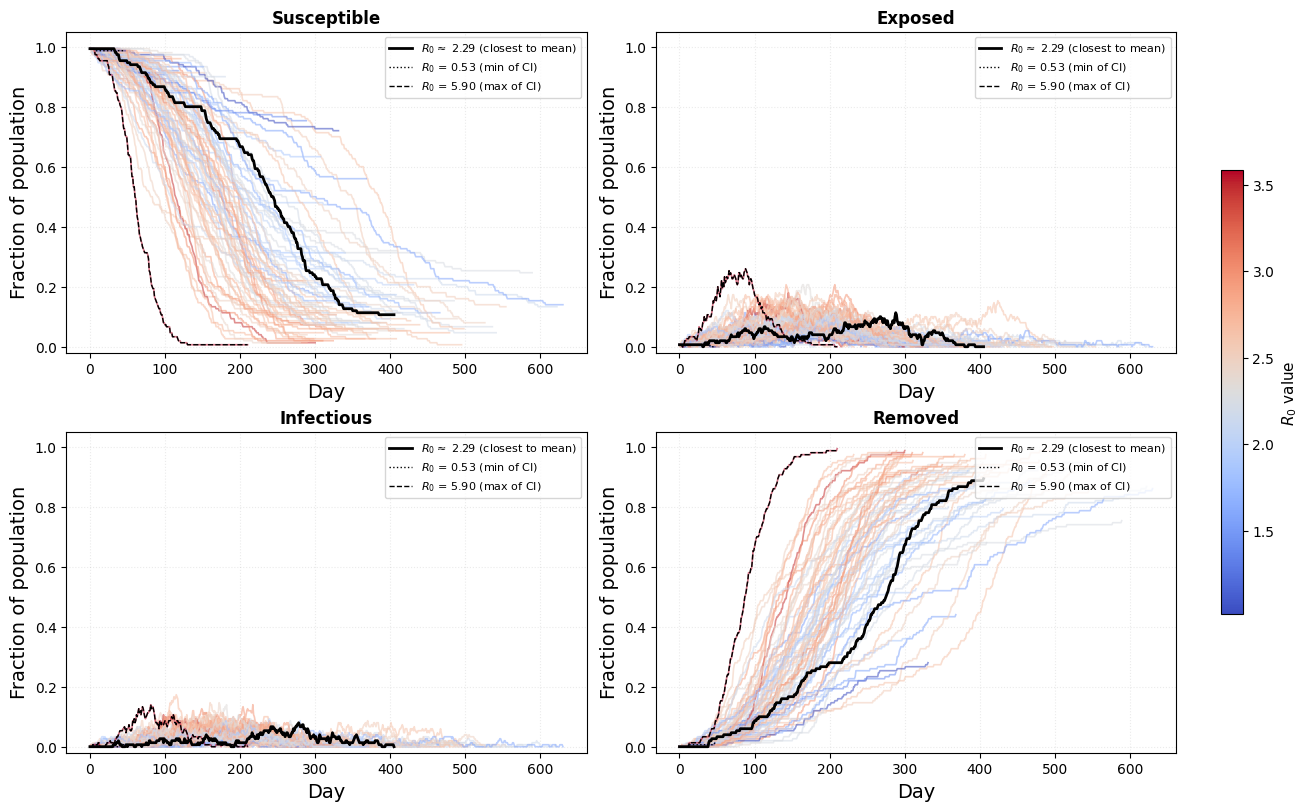

In [6]:
# Plotting
plot_ensemble(results = results, r0_mean = R0_mean, r0_std = R0_std, n_nodes = n_nodes, incubation_days = incubation_days, infectious_days = infectious_days,) # out_path = 'figures/scenario1_trajectories.svg', )


In [7]:
# Statistics

I_peak = []
peak_day = []
total = []

for res in sorted(results, key=lambda r: r["R0"]):
        I = res["I"]
        peak_I   = max(I)
        I_peak.append(peak_I)
        peak_day.append(I.index(peak_I))
        total.append(n_nodes - res["S"][-1])

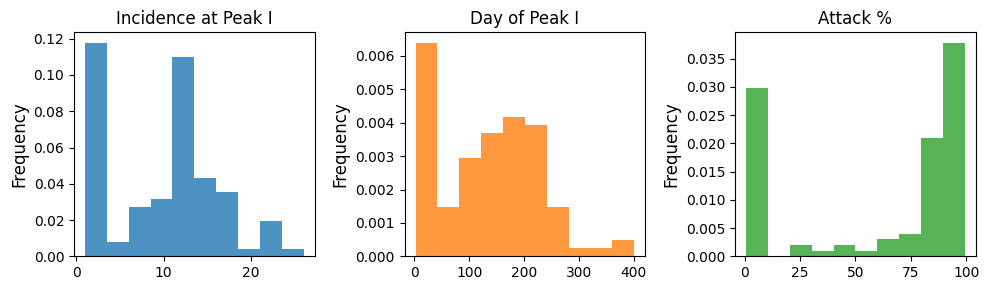

In [8]:
# Plot statistics

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

axes[0].hist(I_peak, color= 'C0', alpha=0.8, density=True)
axes[0].set_title("Incidence at Peak I", fontsize = 12)
#axes[0].set_xlabel("Days from first case", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

axes[1].hist(peak_day, color= 'C1', alpha=0.8, density=True)
axes[1].set_title("Day of Peak I", fontsize = 12)
#axes[1].set_xlabel("Days from first case", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

attack = np.divide(total,n_nodes)*100
axes[2].hist(attack, color= 'C2', alpha=0.8, density=True)
axes[2].set_title("Attack %", fontsize = 12)
#axes[2].set_xlabel("Days from first case", fontsize=12)
axes[2].set_ylabel("Frequency", fontsize=12)

fig.tight_layout()
#fig.savefig('figures/scenario1_stats.svg', bbox_inches='tight')


### Uncertainty on incubation period $T_\alpha$
Consider the full uncertainty over $\alpha$ (respectively, $T_\alpha$).  
A first question is: which distribution shall we use to approximate the uncertainty over $\alpha$? Recent works ([Southall et al.](https://www.sciencedirect.com/science/article/pii/S0022519323000139)) or [(Hong et al.)](https://www.nature.com/articles/s41467-024-53095-7) suggest using a [Gamma distribution](https://en.wikipedia.org/wiki/Gamma_distribution). I just need to get reasonable parameters that can cover the identified interval.  
Then, perform uncertainty, sensitivity and delay analysis.

In [9]:
# Incubation period and its uncertainty 
# (this is the paramerter that is most uncertain. T_gamma, instead is estimated to lie in [7; 14] days with a median of 12, so it's not the priority)

I = [7, 18, 42] # min, median, max of T_alpha; I don't really know if there is a proper distribution, and what that could be
alpha = np.divide(1,I)


#### Estimate parameters for Gamma distribution

In [10]:

# Include the def only here as it's a specific function used only once
def objective(params):
    shape, scale = params

    if shape <= 0 or scale <= 0: # Enforce positivity
        return np.inf

    error = 0.0
    for p, q_target in target.items():
        q_est = gamma.ppf(p, a=shape, scale=scale)
        error += (q_est - q_target)**2
    return error

# Target quantiles (lower CI, median, upper CI)
target = {0.025: 7.0, 0.50: 18.0, 0.975: 42.0}

# Initial guess
x0 = [5.0, 4.0]

result = minimize( objective, x0, bounds=[(1e-6, None), (1e-6, None)])
shape, scale = result.x

print(f"Shape = {shape:.4f}")
print(f"Scale = {scale:.4f}")

# Check fitted quantiles
for p in [0.025, 0.5, 0.975]:
    print(f"Q({p}) = {gamma.ppf(p, a=shape, scale=scale):.2f}")

print(f"Mean = {shape * scale:.2f}")

Shape = 4.7382
Scale = 4.2390
Q(0.025) = 6.27
Q(0.5) = 18.69
Q(0.975) = 41.80
Mean = 20.09


In [11]:
result

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 1.0520995390650238
        x: [ 4.738e+00  4.239e+00]
      nit: 10
      jac: [-3.197e-06 -1.887e-06]
     nfev: 36
     njev: 12
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

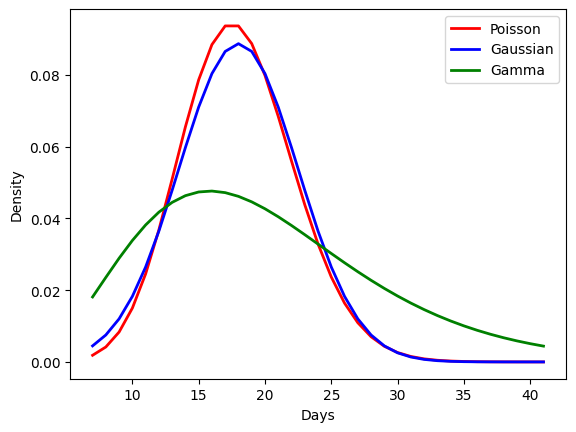

In [12]:
# Compare Poisson, Gaussian with guessed std, and Gamma distributions

x = np.arange(7, 42)

fig = plt.figure()
plt.plot(x, stats.poisson.pmf(x, 18), 'r-', lw=2, label="Poisson") # Poisson
plt.plot(x, stats.norm.pdf(x, loc=18, scale=4.5), 'b-', lw=2, label="Gaussian") # Gaussian, with same mean but made-up std
plt.plot(x, gamma.pdf(x, a=shape, scale=scale), 'g-', lw=2, label="Gamma")
plt.xlabel("Days")
plt.ylabel("Density")
plt.legend()
#fig.savefig('figures/pos_gaus_gamma.pdf', bbox_inches='tight')

#### Run sims for uncertainty and sensitivity analysis

In [13]:
# Set uncertainty for alpha

alpha1_values = sample_infection_gamma(a = shape, scale = scale, n = n) # days
alpha_values = np.divide(1, alpha1_values) # 1/days


(array([11.67364693, 20.27528152, 13.51685435,  6.1440247 ,  3.68641482,
         3.68641482,  1.22880494,  0.61440247,  0.        ,  0.61440247]),
 array([0.02235549, 0.03863146, 0.05490744, 0.07118342, 0.08745939,
        0.10373537, 0.12001135, 0.13628732, 0.1525633 , 0.16883927,
        0.18511525]),
 <BarContainer object of 10 artists>)

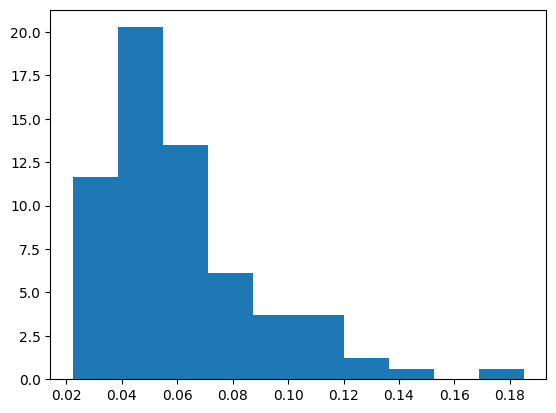

In [14]:
plt.hist(alpha_values, density=True)

##### --- Sensitivity analysis: sweep over values for alpha, then the only stochasticity is in the network


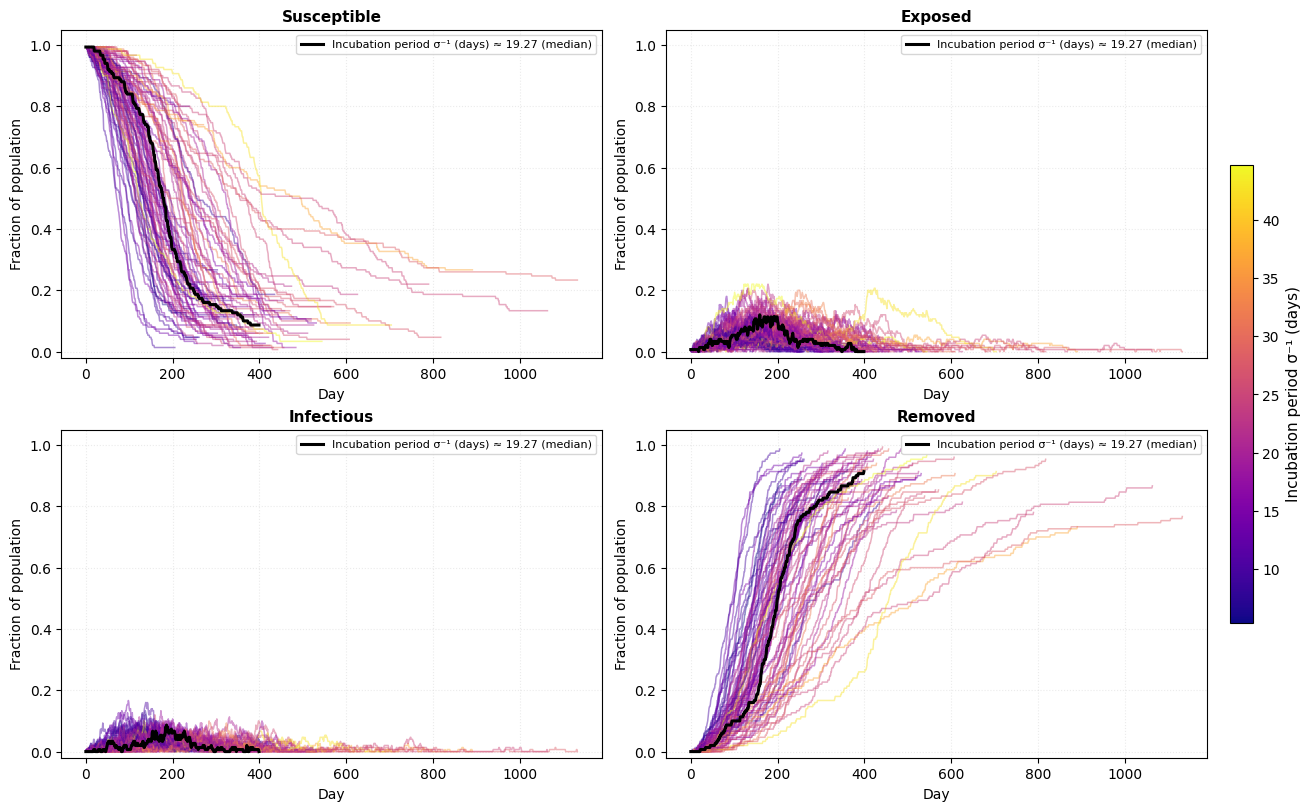

In [15]:

results_sweep_inc = sweep_incubation_range(
            incubation_values = alpha1_values,
            R0                = R0_mean,
            n_nodes           = n_nodes,
            infectious_days   = infectious_days,
            k                 = k,
            p_rewire          = p_rewire,
            base_seed         = base_seed + 20,
            plot              = True,
            #out_path          = "figures/scenario1_trajectories_sweep_inc.svg",
        )

In [16]:
# Statistics

I_peak_sweep_inc = []
peak_day_sweep_inc = []
attack_rate_sweep_inc = []

for res in sorted(results_sweep_inc, key=lambda r: r["incubation_days"]):
        I = res["I"]
        peak_I   = max(I)
        I_peak_sweep_inc.append(peak_I)
        peak_day_sweep_inc.append(I.index(peak_I))
        attack_rate_sweep_inc.append(res["attack_rate"]*100)

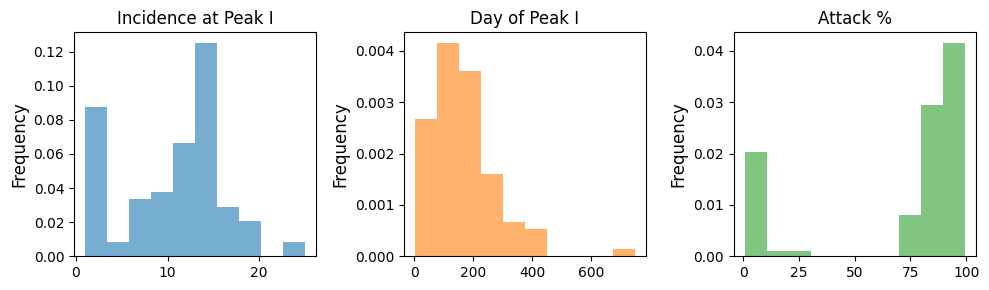

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

axes[0].hist(I_peak_sweep_inc, color= 'C0', alpha=0.6, density=True)
axes[0].set_title("Incidence at Peak I", fontsize = 12)
#axes[0].set_xlabel("Days from first case", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

axes[1].hist(peak_day_sweep_inc, color= 'C1', alpha=0.6, density=True)
axes[1].set_title("Day of Peak I", fontsize = 12)
#axes[1].set_xlabel("Days from first case", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

axes[2].hist(attack_rate_sweep_inc, color= 'C2', alpha=0.6, density=True)
axes[2].set_title("Attack %", fontsize = 12)
#axes[2].set_xlabel("Days from first case", fontsize=12)
axes[2].set_ylabel("Frequency", fontsize=12)

fig.tight_layout()
#fig.savefig('figures/scenario1_stats_sweep_inc.svg', bbox_inches='tight')


In [18]:
# Are these distributions compatible with those without considering explicitly the uncertainty over gamma? 
# Perform Kolmogorov-Smirnov test

#Peak Incidence
statistica_d_sweep_peak, p_value_sweep_peak = stats.ks_2samp(I_peak, I_peak_sweep_inc)

#Peak Day
statistica_d_sweep_day, p_value_sweep_day = stats.ks_2samp(peak_day, peak_day_sweep_inc)

#Attack %
statistica_d_sweep_attack, p_value_sweep_attack = stats.ks_2samp(attack, attack_rate_sweep_inc)

print(f"I peak: stat D = {statistica_d_sweep_peak:.4f}, p-value = {p_value_sweep_peak:.4f}")
print(f"I day: stat D = {statistica_d_sweep_day:.4f}, p-value = {p_value_sweep_day:.4f}")
print(f"Attack rate: stat D = {statistica_d_sweep_attack:.4f}, p-value = {p_value_sweep_attack:.4f}")

I peak: stat D = 0.1067, p-value = 0.5559
I day: stat D = 0.1051, p-value = 0.5779
Attack rate: stat D = 0.1624, p-value = 0.1207


##### --- Explicit uncertainty analysis  
The ensemble answers a different question from the sensitivity analysis above: "what does the epidemic look like when we are uncertain about the true incubation period?"

In [19]:
results_unc_inc = sample_incubation_gamma_network(
            gamma_shape     = shape,
            gamma_scale     = scale,
            n_runs          = n,
            R0              = R0_mean,
            n_nodes         = n_nodes,
            infectious_days = infectious_days,
            k               = k,
            p_rewire        = p_rewire,
            base_seed       = base_seed,
            plot            = False,
            #out_path        = "figures/scenario1_trajectories_unc_inc.svg",
        )

In [20]:
# Statistics

I_peak_unc_inc = []
peak_day_unc_inc = []
attack_rate_unc_inc = []

for res in sorted(results_unc_inc, key=lambda r: r["incubation_days"]):
        I = res["I"]
        peak_I   = max(I)
        I_peak_unc_inc.append(peak_I)
        peak_day_unc_inc.append(I.index(peak_I))
        attack_rate_unc_inc.append(res["attack_rate"]*100)

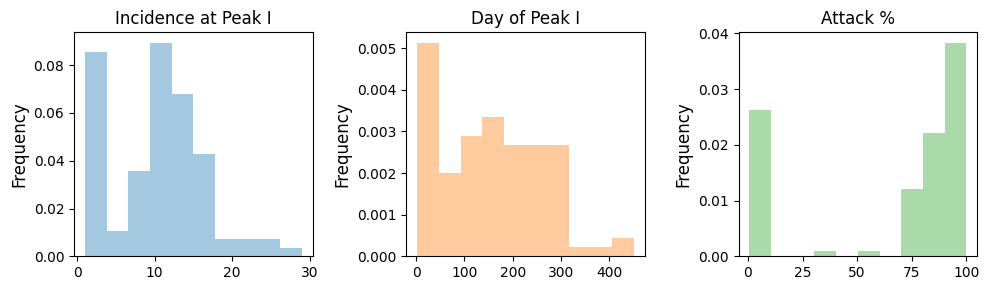

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

axes[0].hist(I_peak_unc_inc, color= 'C0', alpha=0.4, density=True)
axes[0].set_title("Incidence at Peak I", fontsize = 12)
#axes[0].set_xlabel("Days from first case", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

axes[1].hist(peak_day_unc_inc, color= 'C1', alpha=0.4, density=True)
axes[1].set_title("Day of Peak I", fontsize = 12)
#axes[1].set_xlabel("Days from first case", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

axes[2].hist(attack_rate_unc_inc, color= 'C2', alpha=0.4, density=True)
axes[2].set_title("Attack %", fontsize = 12)
#axes[2].set_xlabel("Days from first case", fontsize=12)
axes[2].set_ylabel("Frequency", fontsize=12)

fig.tight_layout()
#fig.savefig('figures/scenario1_stats_unc_inc.svg', bbox_inches='tight')

In [22]:
# Are these distributions compatible with those without considering explicitly the uncertainty over gamma? 
# Perform Kolmogorov-Smirnov test

#Peak Incidence
statistica_d_unc_peak, p_value_unc_peak = stats.ks_2samp(I_peak, I_peak_unc_inc)

#Peak Day
statistica_d_unc_day, p_value_unc_day = stats.ks_2samp(peak_day, peak_day_unc_inc)

#Attack %
statistica_d_unc_attack, p_value_unc_attack = stats.ks_2samp(attack, attack_rate_unc_inc)

print(f"I peak: stat D = {statistica_d_unc_peak:.4f}, p-value = {p_value_unc_peak:.4f}")
print(f"I day: stat D = {statistica_d_unc_day:.4f}, p-value = {p_value_unc_day:.4f}")
print(f"Attack rate: stat D = {statistica_d_unc_attack:.4f}, p-value = {p_value_unc_attack:.4f}")

I peak: stat D = 0.0782, p-value = 0.8776
I day: stat D = 0.1516, p-value = 0.1723
Attack rate: stat D = 0.1024, p-value = 0.6182


#### Delay ODE SEIR model
Considers a deterministic model (no uncertainty over the network, considers all-to-all). Uncertainty only on the incubation period: the function integrates a mean-field ODE where the E→I transition is governed by a Gamma-distributed delay, like in Hong et al (2024). All the other parameters are set as usual, and the $R_0$ matches the usual one.

##### --- Sensitivity analysis 
Draw incubation period once from Gamma, then run ODE SEIR

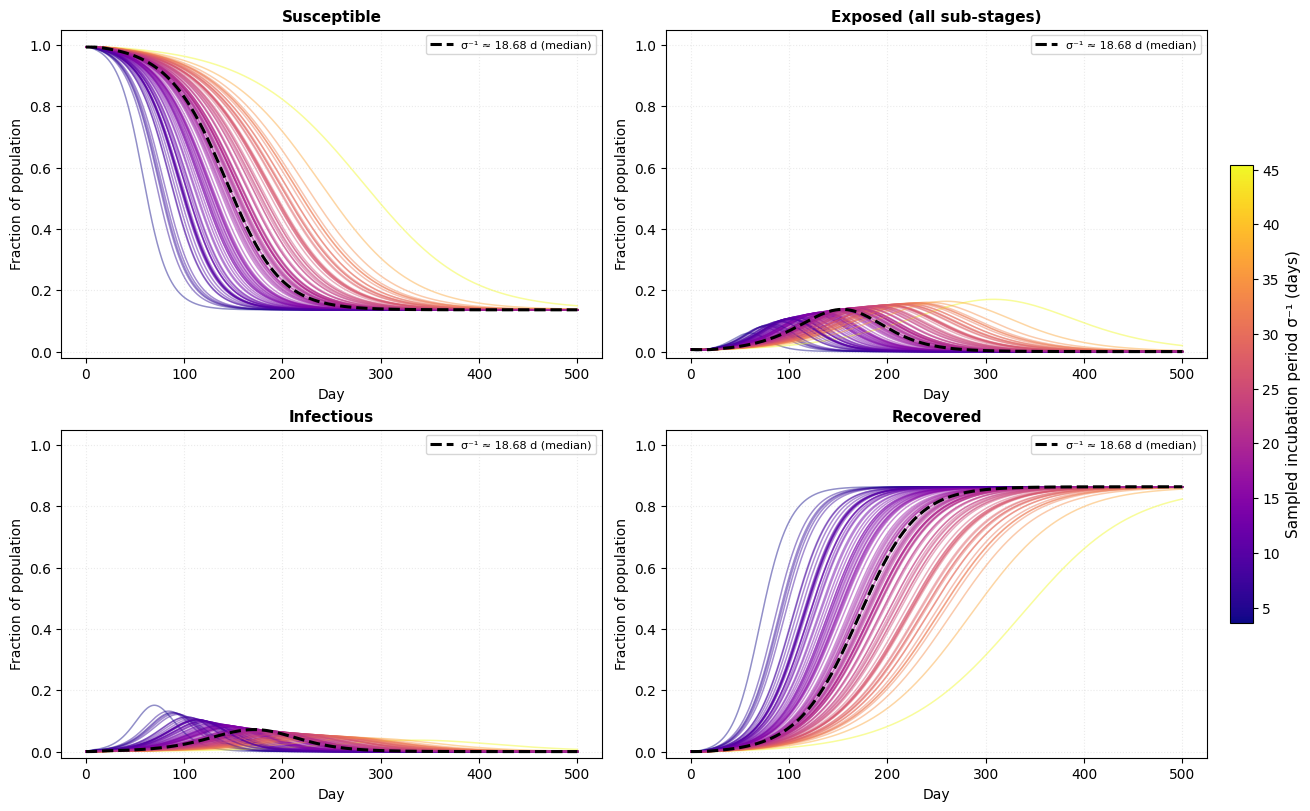

In [23]:
# Sims
t_max = 500

results_delay_inc = seir_delay_gamma_ode_sensitivity(
            gamma_shape     = shape,
            gamma_scale     = scale,
            n_runs          = n,
            R0              = R0_mean,
            n_nodes         = n_nodes,
            infectious_days = infectious_days,
            k_network       = k,
            p_rewire        = p_rewire,
            t_max           = t_max,
            #n_stages        = args.n_stages,
            base_seed       = base_seed,
            plot            = True,
            #out_path        = "figures/scenario1_trajectories_delay_inc_sens.svg",
        )

In [24]:
# Statistics

I_peak_delay_inc = []
peak_day_delay_inc = []
attack_rate_delay_inc = []

for res in sorted(results_delay_inc, key=lambda r: r["incubation_days"]):
        I = res["I"]
        peak_I   = max(I)
        I_peak_delay_inc.append(peak_I)
        peak_day_delay_inc.append(res["peak_day"])
        attack_rate_delay_inc.append(res["attack_rate"]*100)

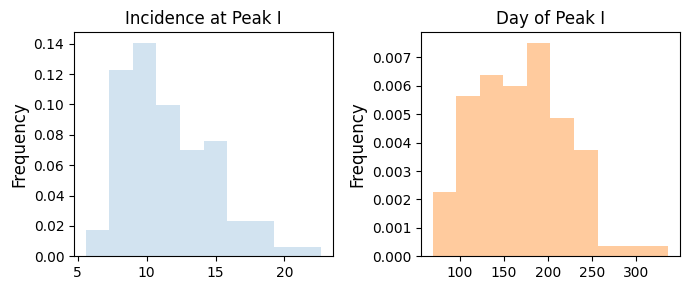

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

axes[0].hist(I_peak_delay_inc, color = 'C0', alpha=0.2, density=True)
axes[0].set_title("Incidence at Peak I", fontsize = 12)
#axes[0].set_xlabel("Days from first case", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

axes[1].hist(peak_day_delay_inc, color = 'C1', alpha=0.4, density=True)
axes[1].set_title("Day of Peak I", fontsize = 12)
#axes[1].set_xlabel("Days from first case", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Attack rate useless, since I always draw them up to exhaustion

fig.tight_layout()
#fig.savefig('figures/scenario1_stats_delay_inc.svg', bbox_inches='tight')

In [26]:
# Are these distributions compatible with those without considering explicitly the uncertainty over gamma? 
# Perform Kolmogorov-Smirnov test

#Peak Incidence
statistica_d_unc_peak, p_value_unc_peak = stats.ks_2samp(I_peak, I_peak_delay_inc)

#Peak Day
statistica_d_unc_day, p_value_unc_day = stats.ks_2samp(peak_day, peak_day_delay_inc)


print(f"I peak: stat D = {statistica_d_unc_peak:.4f}, p-value = {p_value_unc_peak:.4f}")
print(f"I day: stat D = {statistica_d_unc_day:.4f}, p-value = {p_value_unc_day:.4f}")


I peak: stat D = 0.3231, p-value = 0.0000
I day: stat D = 0.3037, p-value = 0.0001


##### --- Full uncertainty analysis 
At each stage within the ODE, the incubation period is drawn from a Gamma distribution.   
Eventually, I plot the effecive incubation period (the expected over the whole chain)

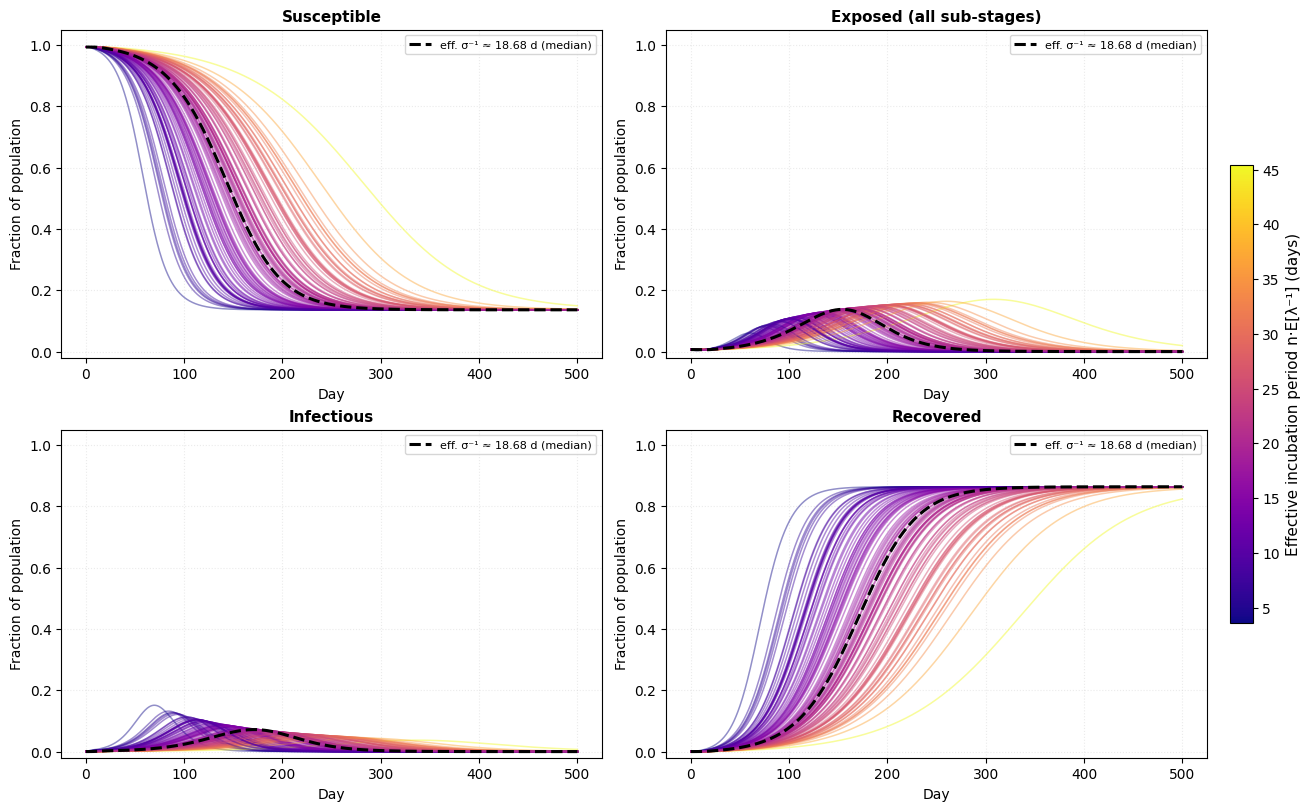

In [27]:
# Sims

t_max = 500

results_delay_unc = seir_delay_gamma_ode_unc(
            gamma_shape     = shape,
            gamma_scale     = scale,
            n_runs          = n,
            R0              = R0_mean,
            n_nodes         = n_nodes,
            infectious_days = infectious_days,
            t_max           = t_max,
            #n_stages        = args.n_stages,
            base_seed       = base_seed,
            plot            = True,
            #out_path        = "figures/scenario1_trajectories_delay_inc_unc.svg",
        )

## Scenario 2: effects of network


### Impact of k 
Keep the other parameters at median values, and change k -> what happens if people have more close (but local) contacts

In [28]:
# Increase the number of nodes to have lower stochasticity

k_s = [4, 6, 8, 10, 12, 14, 16, 18, 20] 
n_nodes_k = 500 # need large population to test higher k

results_k = []
for idx, k in enumerate(k_s):
    S, E, I, R, _ = run_seir(
        n_nodes         = n_nodes_k,
        R0              = R0_mean,
        incubation_days = incubation_days,
        infectious_days = infectious_days,
        k               = k,
        p_rewire        = p_rewire,
        seed            = base_seed + idx,
    )
    results_k.append({"k": k, "S": S, "E": E, "I": I, "R": R})



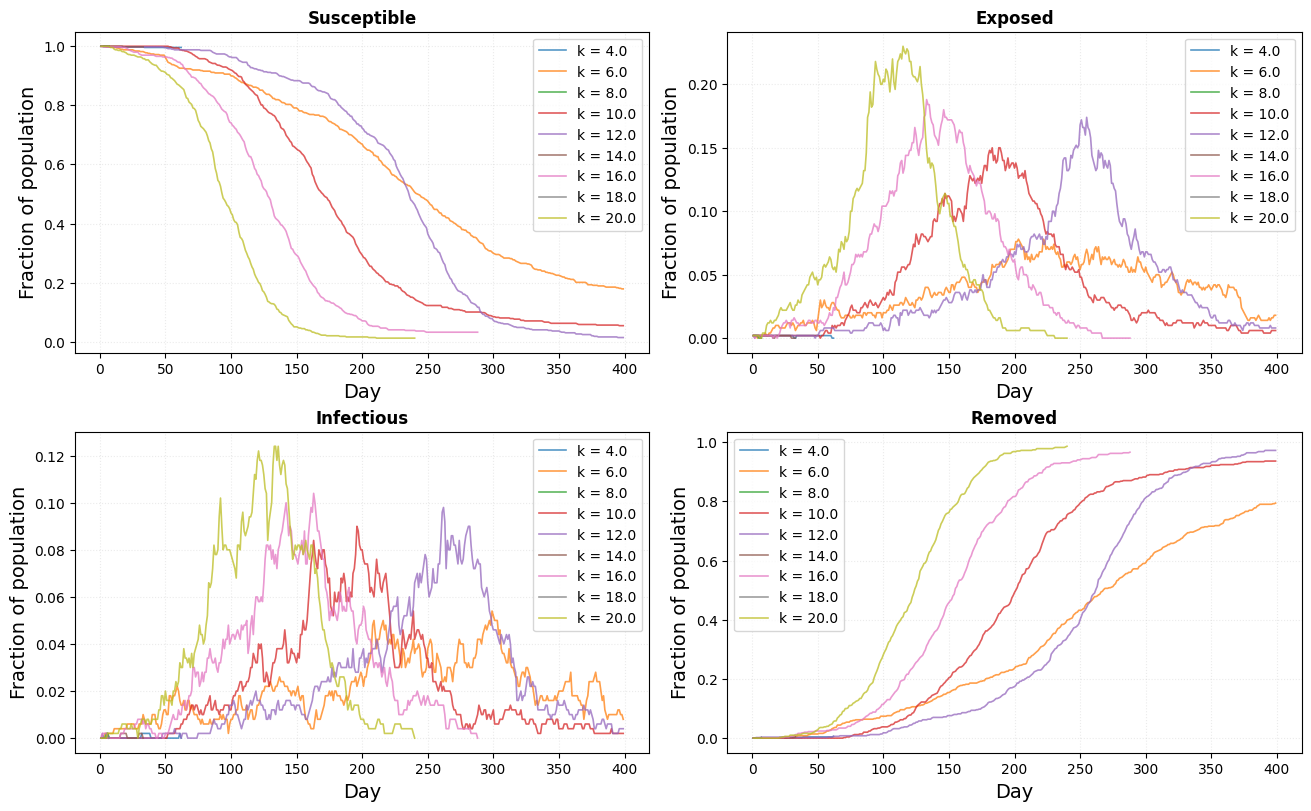

In [29]:
plot_ensemble_netparam(cutoff_time = 400, results = results_k, r0_mean = R0_mean, which_param = "k", k_mean = 10, n_nodes = n_nodes_k, ) #out_path = 'figures/scenario2-1_trajectories.pdf', )


In [30]:
# Make sure that, qualitatively, I get the same results even on the small network with n=150

k_s = [4, 6, 8, 10, 12, 14, 16, 18, 20] 
n_nodes_k = 150 # comparison with the default parameter linked to the ship size

results_k_1 = []
for idx, k in enumerate(k_s):
    S, E, I, R, _ = run_seir(
        n_nodes         = n_nodes_k,
        R0              = R0_mean,
        incubation_days = incubation_days,
        infectious_days = infectious_days,
        k               = k,
        p_rewire        = p_rewire,
        seed            = base_seed + idx,
    )
    results_k_1.append({"k": k, "S": S, "E": E, "I": I, "R": R})


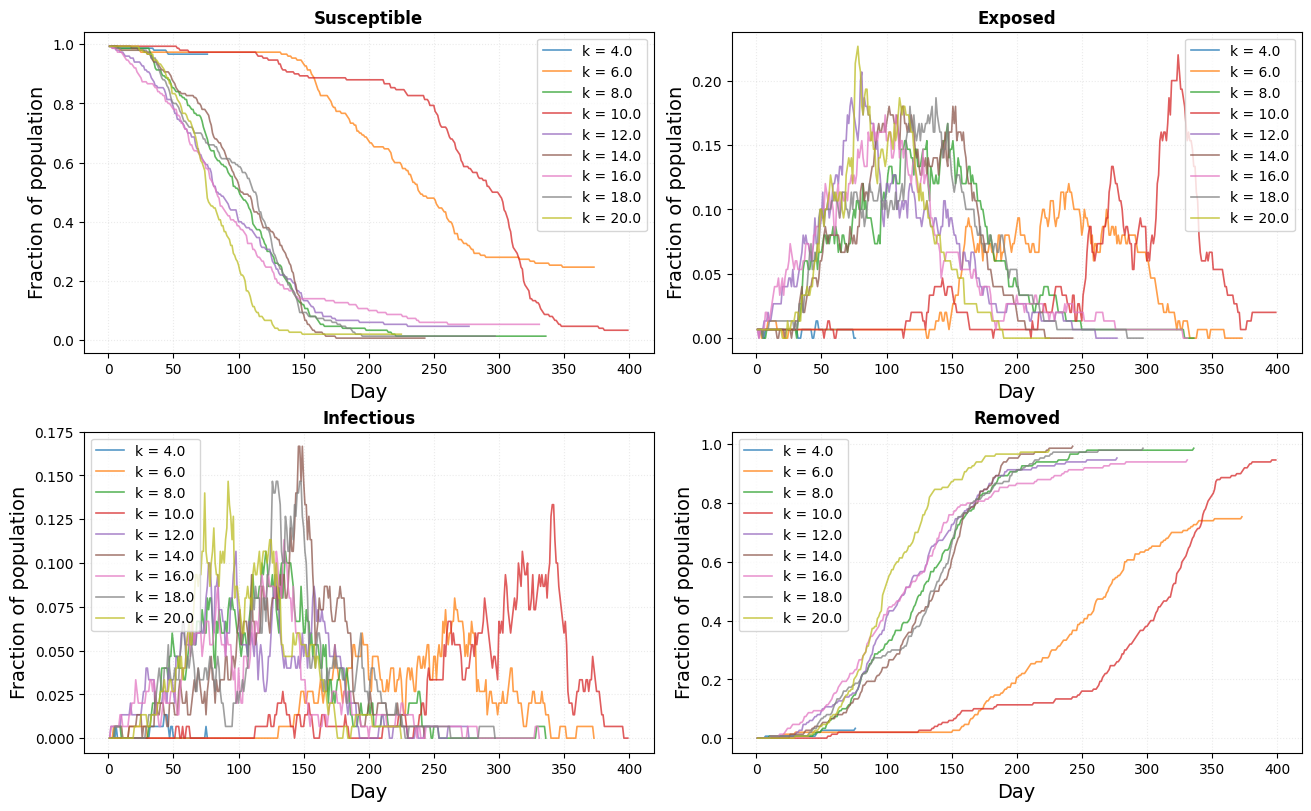

In [31]:
plot_ensemble_netparam(cutoff_time = 400, results = results_k_1, r0_mean = R0_mean, which_param = "k", k_mean = 10, n_nodes = n_nodes_k, ) #out_path = 'figures/scenario2_trajectories.pdf', )


### Impact of p_rewire
What happens if nodes have more and more long-range contacts (such as in case of COVID-19 which, being airborne, could spread on longer distances). The limit p_rewire = 1 converges to the all-to-all SEIR compartment model.

In [32]:
# Increase the number of nodes to have lower stochasticity

p_s = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] 
n_nodes_k = 500 # need large population to test higher k

results_p = []
for idx, p in enumerate(p_s):
    S, E, I, R, _ = run_seir(
        n_nodes         = n_nodes_k,
        R0              = R0_mean,
        incubation_days = incubation_days,
        infectious_days = infectious_days,
        k               = k,
        p_rewire        = p,
        seed            = base_seed + 2*idx,
    )
    results_p.append({"p": p, "S": S, "E": E, "I": I, "R": R})

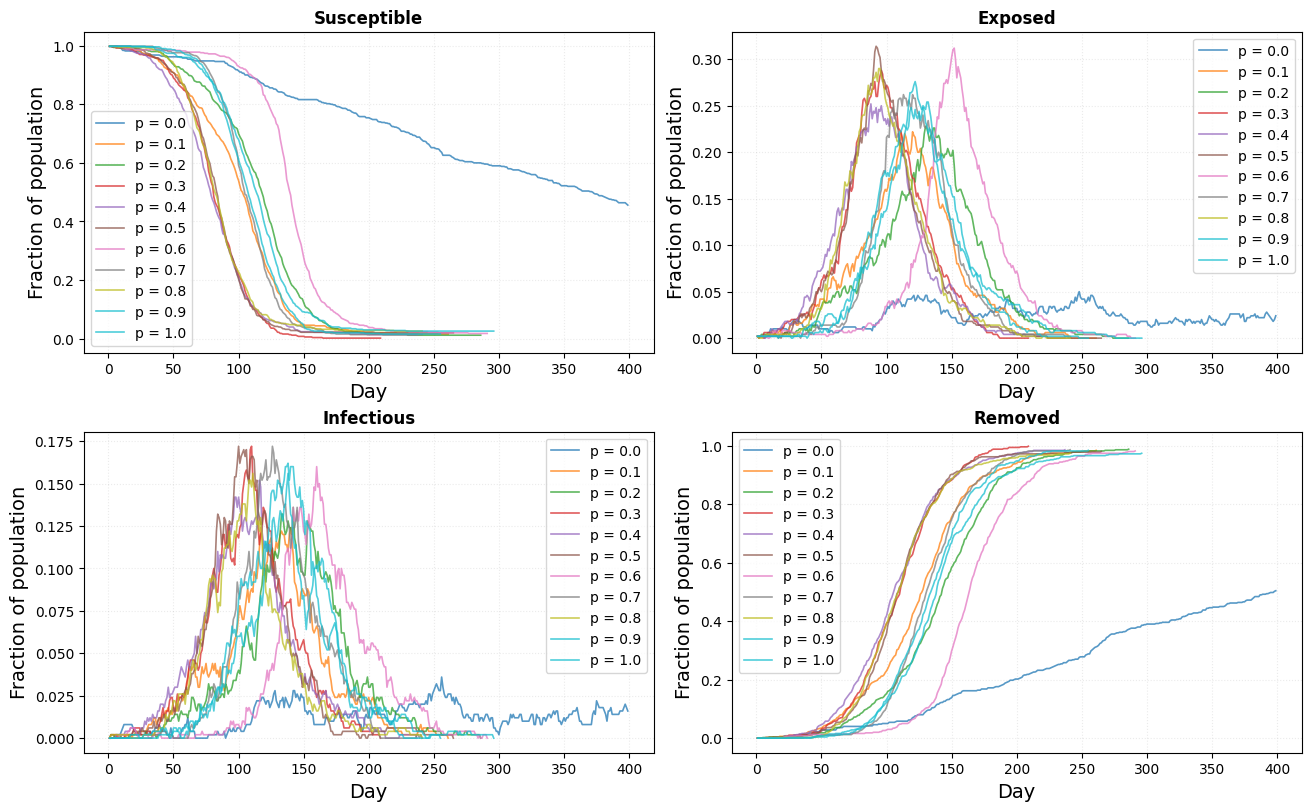

In [33]:
plot_ensemble_netparam(cutoff_time = 400, results = results_p, r0_mean = R0_mean, which_param = "p", k_mean = 10, n_nodes = n_nodes_k, ) #out_path = 'figures/scenario2-2_trajectories.pdf', )


### Combination: k and p_rewire together
Check what happens if we combine both network effects. Since, so far, all outbreaks lasted for a maximum of 4 months (120 days), I use at first the cumulative number of cases (which matters for heatlhcare, as they translate into hospitalizations and fatalioties with a very high CFR) by d=120

In [34]:
# All commented so that, if RUN ALL, it doesn't get run
'''
# Sweep

p_s1 = np.linspace(0,1,21)
k_s1 = np.linspace(4,20,17, dtype=int)
n_nodes_k = 500 # need large population to test higher k
horizon = 120 # consider cumnulative cases up to 120 days (approx 4 months)

data = sweep_net_seir(k_values = k_s1, p_values = p_s1, R0 = R0_mean, n_nodes = n_nodes_k, incubation_days = incubation_days, infectious_days = infectious_days, horizon = horizon, n_replicates = 30, base_seed = base_seed)
'''

'\n# Sweep\n\np_s1 = np.linspace(0,1,21)\nk_s1 = np.linspace(4,20,17, dtype=int)\nn_nodes_k = 500 # need large population to test higher k\nhorizon = 120 # consider cumnulative cases up to 120 days (approx 4 months)\n\ndata = sweep_net_seir(k_values = k_s1, p_values = p_s1, R0 = R0_mean, n_nodes = n_nodes_k, incubation_days = incubation_days, infectious_days = infectious_days, horizon = horizon, n_replicates = 30, base_seed = base_seed)\n'

In [35]:
# Commented for the same reason as above
# np.save('data/sweep_k_p.npy', data)

In [36]:
# Here are the sweep result saved
data = np.load('data/sweep_k_p.npy')

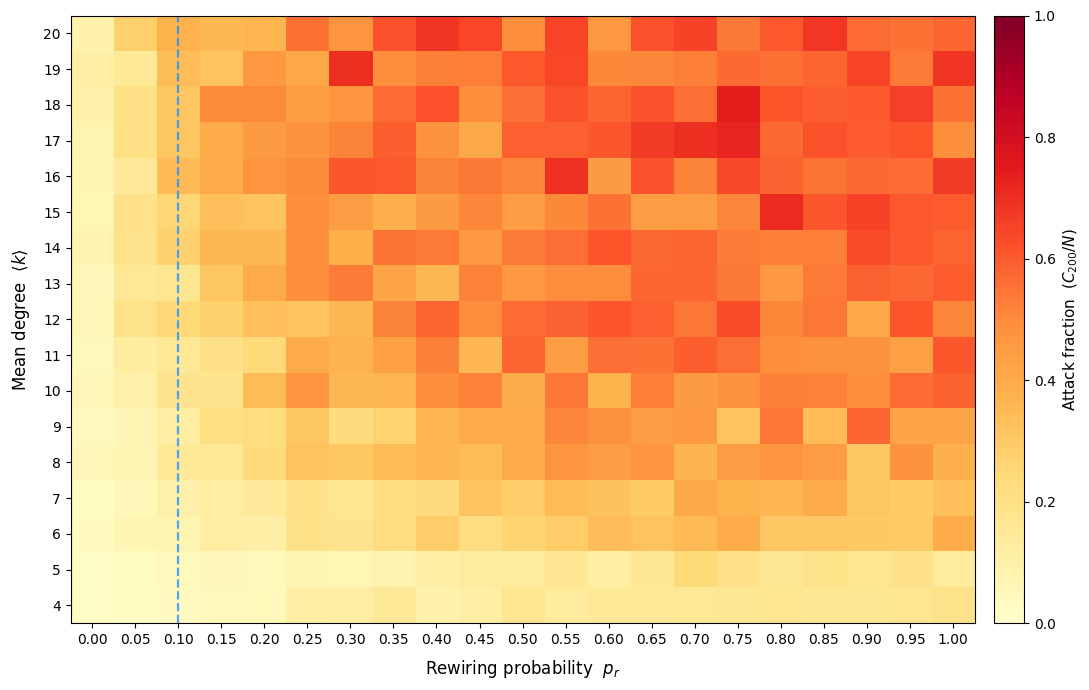

In [37]:
# Plot heatmap
p_s1 = np.linspace(0,1,21)
k_s1 = np.linspace(4,20,17, dtype=int)
n_nodes_k = 500 # need large population to test higher k
horizon = 200 # consider cumnulative cases up to 200 days (approx 5 months)

plot_heatmap(data = data, k_values = k_s1, p_values = p_s1, R0 = R0_mean, n_nodes = n_nodes_k, horizon = horizon, n_replicates = 30, incubation_days = incubation_days, infectious_days = infectious_days, )
            #out_path = 'figures/scenario2_heatmap.svg',)

## Scenario 3: tracing and isolation of exposed and infectious people
Then, I can compare the rates with those extracted from COVID-19 (Proverbio et al., 2021).  

Similarly to that publication, I use rates $\chi$ for draining E (i.e., exposed individual are detected and removed before becoming infectious with a rate $\chi$, and moved to a compartment IS - isolated) and rate $\eta$ for removing the detected Infectious individuals from transmission, moving them to compartment Q (Quarantined). In both cases, I assume that people from IS and Q are removed with the same rate $\gamma$ (there is no change in the biology of the disease). 

The simulations are performed on a network (we just saw that an SEIR is too much of a crude approximation; in any case, since the $R_0$ of hantavirus is very close to that of COVID-19, the results from Proverbio et al (2021) would hold true in case of an all-to-all transmission.  
The rates become effective after a certain time T_interventions (in days).  

Due to these rate, the effective $R_{eff}$ after T_interventions become as in Eq. (1) of Proverbio et al (2021). 


In [38]:
# Make simulations with interventions. All other parameters are set as default, using median values for epidemiological terms

# Scalar rates, intervention from day 30

# Note that, in case of COVID-19, there was also a significant \rho (reduced transmission due to social distancing etc (Proverbio et al. 2021. ). 
# Some \rho-effect was also present on the MV Hondius, but it is unknown.
# Here, instead, I assume that there is no change at all in transmission, but only testing and tracing

chi = 0.001
eta= 0.001

# Sim
# IS stands for T in the paper (isolated and traced)
S, E, I, R, IS, Q, ss = run_seir_intervention(
    n_nodes=n_nodes, R0=R0_mean,
    incubation_days=incubation_days, infectious_days=infectious_days,
    t_intervention = 30,  # In both the 2018 and 2026 outbreak, it took about a month to strat with the non-pharmaceutical interventions, from the onset of the first case (also owing to the longer incubation period)
    chi = chi,    # 10% of E nodes isolated per day
    eta = eta,    # 20% of I nodes quarantined per day
    k=6, seed=base_seed + 20,
)

# # Time-varying rates: ramp up testing over 60 days (not include in the paper, just a test)
# chi_ramp = list(np.linspace(0.02, 0.30, 60))
# eta_ramp = list(np.linspace(0.05, 0.40, 60))
# S, E, I, R, IS, Q, ss = run_seir_intervention(
#     n_nodes=1000, R0=R0_mean, t_intervention=30,
#     chi=chi_ramp, eta=eta_ramp,
# )

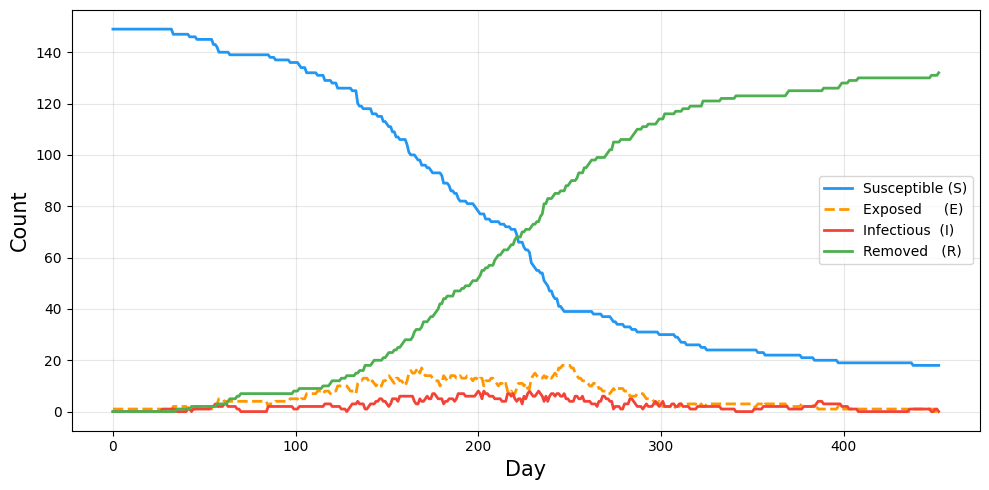

In [39]:
plot_tseries(n_nodes, R0_mean, incubation_days, infectious_days,
        superspreading, k_disp,
        S, E, I, R, ss)

### Combined effect of $\chi$ and $\eta$
First, on the attack rate at t=200 (using simulations), then on $R_{eff}$ using the formula.

In [40]:
# Sweep
'''
chi_s1 = np.linspace(0.0,0.1,21)
eta_s1 = np.linspace(0.0,0.1,21)
n_nodes_k = 500 # need large population to test higher k
horizon = 200 # consider cumnulative cases up to 120 days (approx 4 months)
t_intervention  = 30

data_chi_eta = sweep_mitigation_seir(k_value = 6, p_value = 0.1, R0 = R0_mean, n_nodes = n_nodes_k, chi_values = chi_s1, eta_values = eta_s1, t_intervention  = t_intervention, incubation_days = incubation_days, infectious_days = infectious_days, horizon = horizon, n_replicates = 30, base_seed = base_seed)
'''

'\nchi_s1 = np.linspace(0.0,0.1,21)\neta_s1 = np.linspace(0.0,0.1,21)\nn_nodes_k = 500 # need large population to test higher k\nhorizon = 200 # consider cumnulative cases up to 120 days (approx 4 months)\nt_intervention  = 30\n\ndata_chi_eta = sweep_mitigation_seir(k_value = 6, p_value = 0.1, R0 = R0_mean, n_nodes = n_nodes_k, chi_values = chi_s1, eta_values = eta_s1, t_intervention  = t_intervention, incubation_days = incubation_days, infectious_days = infectious_days, horizon = horizon, n_replicates = 30, base_seed = base_seed)\n'

In [41]:
# Commented for the same reason as above
# np.save('data/sweep_chi_eta.npy', data_chi_eta)

In [42]:
# Here are the sweep result saved
data_chi_eta = np.load('data/sweep_chi_eta.npy')

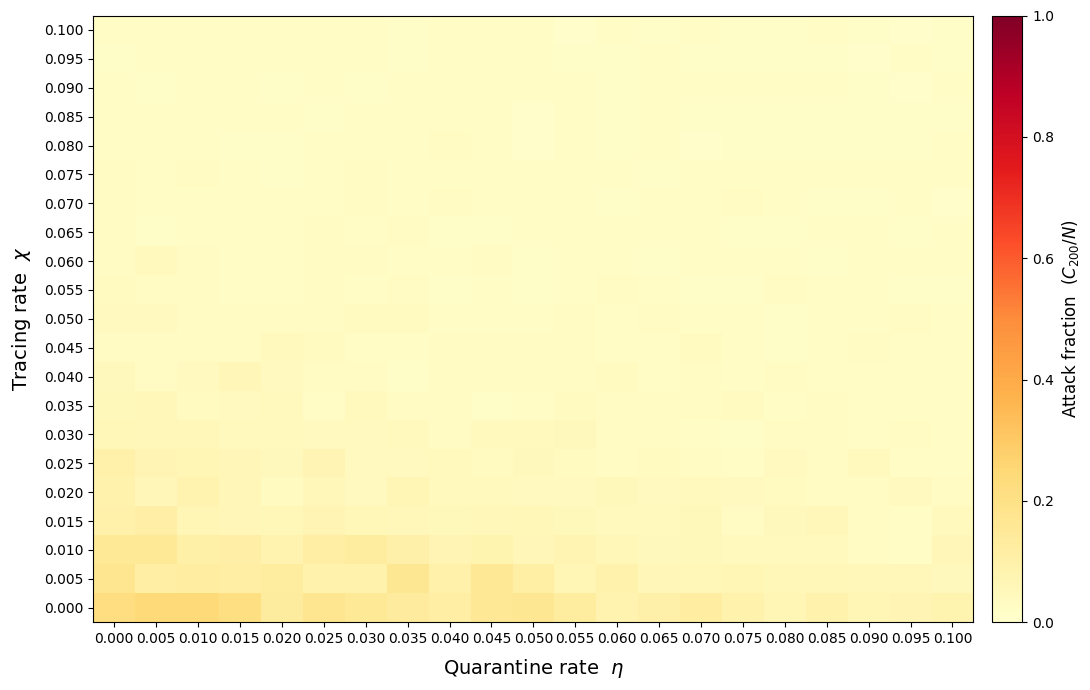

In [43]:
# Plot heatmap
eta_s1 = np.linspace(0.0,0.1,21)           # eta
chi_s1 = np.linspace(0.0,0.1,21) # chi
n_nodes_k = 500 # need large population to test higher k
horizon = 200 # consider cumnulative cases up to 200 days (approx 5 months)

plot_heatmap_interventions(data = data_chi_eta, chi_values = chi_s1, eta_values = eta_s1, R0 = R0_mean, n_nodes = n_nodes_k, horizon = horizon, n_replicates = 30, incubation_days = incubation_days, infectious_days = infectious_days, )
            #out_path = 'figures/scenarioMitigation_heatmap.svg',)

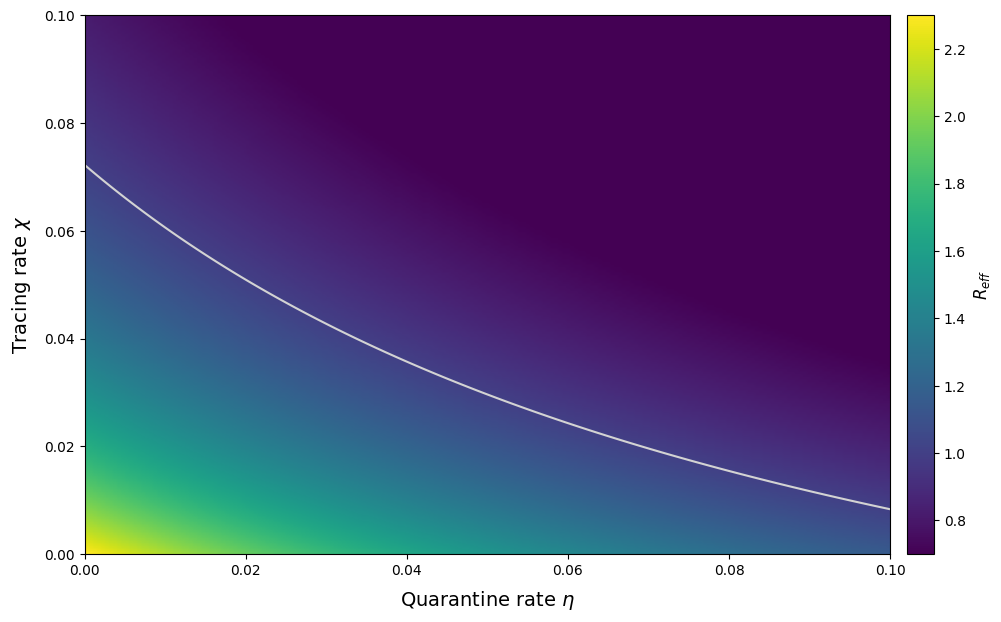

In [44]:
# R_eff as function of mitigation rates

etas = np.linspace(0.0,0.1,201)
chis = np.linspace(0.0,0.1,201)
Reffs = np.zeros((201, 201))
X, Y = np.meshgrid(chis, etas)

for i, chi in enumerate(chis):
    for j, eta in enumerate(etas):
        Reffs[i, j] = R0_mean * ((1/infectious_days) / ((1/infectious_days) + eta)) * ((1/incubation_days) / ((1/incubation_days) + chi))

Reff_plot    = Reffs[::-1]
chi_labels_rev = chis[::-1]


fig, ax = plt.subplots(figsize=(11, 7))
im   = ax.imshow(Reff_plot, extent=[0, 0.1, 0, 0.1], aspect = "auto", vmin   = 0.7, vmax   = 2.3, origin = "upper",)
levels = [1.0] 
plt.contour(X, Y, Reffs, levels=levels, colors='lightgrey')

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10) 
ax.set_xlabel("Quarantine rate $\\eta$", fontsize=14, labelpad=8)
ax.set_ylabel("Tracing rate $\\chi$",  fontsize=14, labelpad=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("$R_{eff}$", fontsize=12)
#fig.savefig('figures/scenarioMitigation_Reff.svg', bbox_inches='tight')

## Scenario 4: consider asymptomatic cases for the control of the outbreak
The model is modified as S - E - A(asympt) - I - R. Do not consider the tracing of contacts from E. Assume that asymptomatic cases cannot be traced, and only I (infectious symptomatic) are quarantined.  
See what changes in the possibility of controlling the outbreak (by varying $eta$, depending on the fraction (1-$\theta$) of people that show pre-symptomatic transmission, and on the period $T_s$ that asymptomatics take to become fully symptomatic.

### Effect of $\theta$ (portion of symptomatics)
I fix $T_s$ (time for A to become I). I fix the commpanion parameter $a$ as $a=\frac{T_\alpha}{T_\alpha - T_s}$ (by definition in the code).  
For $T_s$, I use a default of 10 days ([Ferres, 2007)](https://academic.oup.com/jid/article-abstract/195/11/1563/943825) observed viral RNA between 5 and 10 days before symptoms onset).  
Since $T_\alpha$ = 18 and the required $T_s = 10$, I fix $a=2.25$.

In [4]:
etas = np.linspace(0.0,0.1,21)
thetas = np.linspace(0.0,1.0,21)
n_nodes = 500

#data1 = sweep_eta_theta(etas, thetas, R0 = R0_mean, n_nodes = n_nodes, a = 2.25, incubation_days = incubation_days, infectious_days = infectious_days, t_intervention = 30, horizon = 200)
#np.save('data/data_asympt_theta.npy', data1)

In [5]:
data_asympt_theta = np.load('data/data_asympt_theta.npy')

  Saved: figures/scenarioAsymptomatic_theta.svg


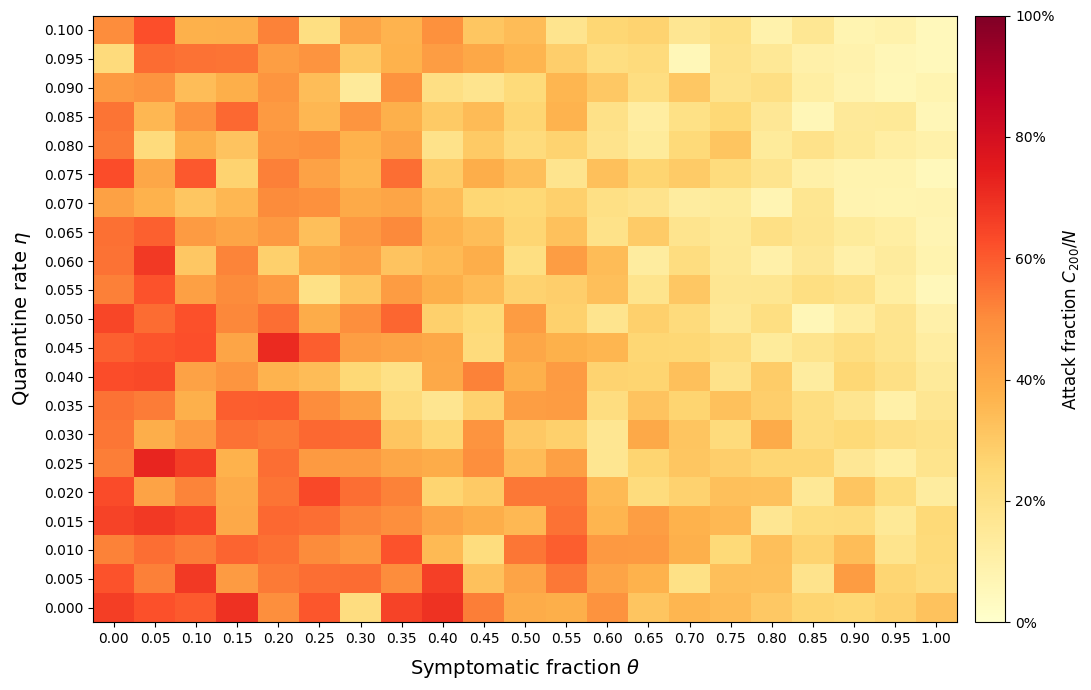

In [7]:
plot_heatmap_asymptomatic(data_asympt_theta, thetas, etas, 'Symptomatic fraction $\\theta$', 'Quarantine rate $\\eta$', '', out_path = 'figures/scenarioAsymptomatic_theta.svg',)

### Effect of $T_s$ (time from A to I)
I use a default $\theta=0.4$, corresponding to the asymptomatic fraction of indigenous populations (those who stay with prolongued contacts with the virus) [(Ferrer 1998)](https://d1wqtxts1xzle7.cloudfront.net/40082578/High_prevalence_of_hantavirus_infection_20151116-16844-11cuxdw-libre.pdf?1447718124=&response-content-disposition=inline%3B+filename%3DHigh_prevalence_of_hantavirus_infection.pdf&Expires=1785839668&Signature=g2q4XQAhqM2x~jCWH17~-GJfatE436cw6hUyj03r4Yl1CSXHkjz1p4XSGsTYivDqdxJ93OPZat9ayv2tIy0~r00nOMoXhuWUwsl9VMw-sm1101pTEVm4PWswdiK~~30XnTvNcYfskKkAcJVBGn5JUBxnHvovyFK07cwNg-F3LB0RTozp~ScmWQpVK93Jf~h7ZOX73EQ1gbM7gHhushgly9pznGTUAB~-L1d2vbRVJcqG-tFkT7j6zHBtDx8TMxuth7glat-Yku8f0RO99NQGGTLnkmjnwcol8mEpKhbPVcNbfMNHHsBvtkUFoPZMN-ZW-9Qnb20ytu5w5spNlbF7FQ__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)

In [21]:
etas = np.linspace(0.0,0.1,21)
tss = np.linspace(1,17,17)
n_nodes = 500

# data2 = sweep_eta_ts(etas, tss, theta = 0.5, R0 = R0_mean, n_nodes = n_nodes, incubation_days = incubation_days, infectious_days = infectious_days, t_intervention = 30, horizon = 200)
# np.save('data/data_asympt_ts.npy', data2)

  [██████████████████████████████████████████████████] 100.0%  η=0.10  T_s=17.00  AF=0.249


In [22]:
data_asympt_ts = np.load('data/data_asympt_ts.npy')

  Saved: figures/scenarioAsymptomatic_tss.svg


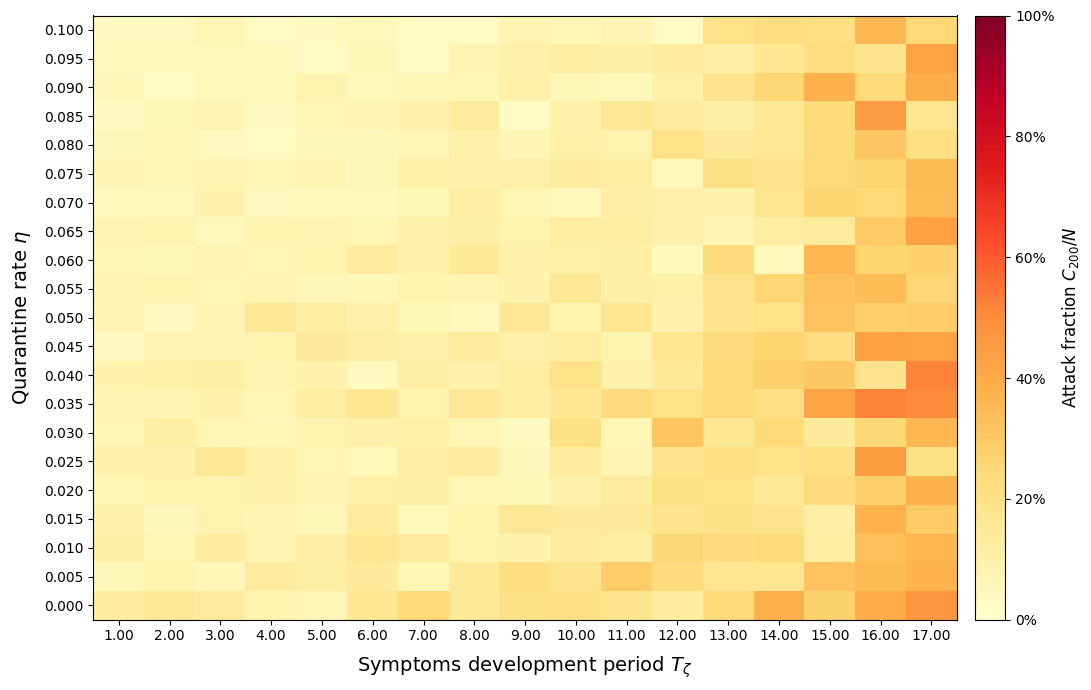

In [23]:
plot_heatmap_asymptomatic(data_asympt_ts, tss, etas, 'Symptoms development period $T_{\\zeta}$', 'Quarantine rate $\\eta$', '', out_path = 'figures/scenarioAsymptomatic_tss.svg',)


## Scenario 5: superspreading events 
Consider superspreaders (an add-on to Scenario 1, to see what happens if there are superspreading events and if the outbreak becomes dramatically more serious).  
Use values fit in the Hanta_analysis notebook. 

In [19]:
sweep1 = sweep_kd(   # R0 min
    kd_values    = [0.05, 0.1, 0.394, 1.0, 5.0],
    R0           = 1.33,
    n_nodes      = 500,
    n_replicates = 30,
    k            = 6,
    horizon      = 200,
    incubation_days = incubation_days,
    infectious_days = infectious_days
)

sweep2 = sweep_kd(   # R0 mean
    kd_values    = [0.05, 0.1, 0.394, 1.0, 5.0],
    R0           = R0_mean,
    n_nodes      = 500,
    n_replicates = 30,
    k            = 6,
    horizon      = 200,
    incubation_days = incubation_days,
    infectious_days = infectious_days
)

sweep2 = sweep_kd(   # R0 mean
    kd_values    = [0.05, 0.1, 0.394, 1.0, 5.0],
    R0           = 3.27,
    n_nodes      = 500,
    n_replicates = 30,
    k            = 6,
    horizon      = 200,
    incubation_days = incubation_days,
    infectious_days = infectious_days
)

  [██████████████████████████████████████████████████] 100.0%  k_d=5.000  rep=30/30  AF=0.990  SS=02
  [██████████████████████████████████████████████████] 100.0%  k_d=5.000  rep=30/30  AF=1.000  SS=00
  [██████████████████████████████████████████████████] 100.0%  k_d=5.000  rep=30/30  AF=1.000  SS=31


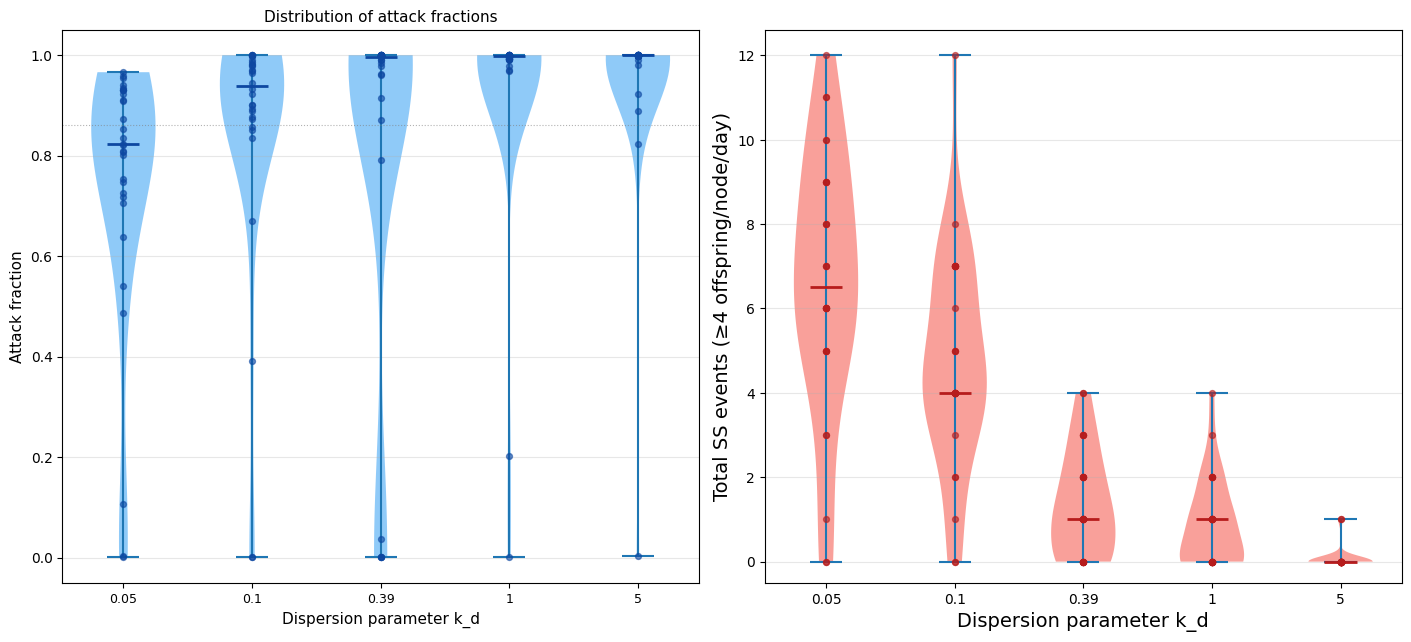

In [18]:
fig = plt.figure
plot_distributions(sweep1) #, out_path="ss_sweep.png")
plot_distributions(sweep2) #, out_path="ss_sweep.png")
plt.show()